# 07 — Checklist del Cap. 40 sul Caso C, versione corretta (v0.10)

Stessa checklist del notebook 05, rifatta dopo le correzioni del notebook 06:

* **P1** kernel della traccia esatto sulla sfera (von Mises–Fisher) al posto di quello gaussiano 1D;
* **P2** raggio della calotta non più degenere quando `arccos(best @ best)` arrotonda sopra 0;
* **P3** stadio 1 iterato: Ω̂_n → (μ̂_E, σ̂_E) → di nuovo Ω_n con prior plug-in $N(\hat\mu_E, \hat\sigma_E)$ su $E_n$ → stadio 2.

Setup identico al notebook 05: $\mu_E\sim U(2.5, 4.0)$ MeV, $\sigma_E$ log-uniforme in
$[0.2, 0.6]$ MeV, $\Omega_n$ isotropa; stesse stime puntuali, stessi intervalli, stessi M.

| N | 50 | 150 | 300 | 1000 |
|---|---|---|---|---|
| esperimenti M | 200 | 200 | 100 | 40 |

Il run completo ora dura **circa 10 minuti con 3 processi** (v0.9: circa 45 minuti con 6):

```bash
OMP_NUM_THREADS=1 systemd-run --user --scope -p MemoryMax=5G -p MemorySwapMax=0 \
    python scripts/caso_C_checklist.py 3
```

Lo script salva i risultati grezzi in `outputs/caso_C_checklist_results.pkl`. Questo notebook li
rilegge e ricalcola **tutte** le tabelle con `validate`, affiancando i numeri v0.9 del notebook 05
(scritti a mano, colonna "v0.9"). Tutti i risultati sono **(c)** salvo dove indicato.

**Etichette.** (a) fatto consolidato · (b) stima toy con assunzioni esplicite · (c) verificato
con Monte Carlo · (d) ipotesi da testare.

In [1]:
import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

sys.path.insert(0, str(Path("..") / "scripts"))
from caso_C_checklist import collect, rms          # stessa riduzione dei dati dello script
from riptide_toy import validate

plt.rcParams["figure.dpi"] = 110
with open(Path("..") / "outputs" / "caso_C_checklist_results.pkl", "rb") as f:
    run = pickle.load(f)
LEVELS, N_ROB = run["LEVELS"], run["N_ROBUSTNESS"]
N_VALUES = sorted(n for n, _ in run["N_M"])
T = {n: collect(run["results"], n) for n in N_VALUES}
print("esperimenti per N:", {n: len(T[n]["mu_true"]) for n in N_VALUES})

# v0.9 (notebook 05): kernel piatto, calotta con bug, stadio 1 con prior largo
V09 = {
    "bias_mu": {50: (-0.018, 0.006), 150: (-0.020, 0.004), 300: (-0.021, 0.004), 1000: (-0.019, 0.003)},
    "bias_ls": {50: -0.14, 150: -0.05, 300: -0.02, 1000: 0.01},
    "err_om": {50: 2.66, 150: 1.52, 300: 1.09, 1000: 0.58},
    "rms_mu": {50: 0.082, 150: 0.055, 300: 0.045, 1000: 0.028},
    "std_mu": {50: 0.088, 150: 0.051, 300: 0.035, 1000: 0.019},
    "rms_ls": {50: 0.47, 150: 0.26, 300: 0.16, 1000: 0.052},
    "std_ls": {50: 0.40, 150: 0.18, 300: 0.11, 1000: 0.057},
    "rms_om": {50: 3.06, 150: 1.74, 300: 1.24, 1000: 0.67},
    "sig_om": {50: 3.87, 150: 2.21, 300: 1.57, 1000: 0.82},
    "pull_mu": {50: (-0.25, 0.98), 150: (-0.40, 0.98), 300: (-0.62, 1.14), 1000: (-1.05, 1.05)},
    "pull_ls": {50: (-0.10, 0.97), 150: (-0.02, 1.05), 300: (0.00, 1.06), 1000: (0.17, 0.87)},
    "pull_om": {50: 0.79, 150: 0.78, 300: 0.79, 1000: np.inf},
    "cov_mu": {50: (0.69, 0.90, 0.96), 150: (0.66, 0.88, 0.94), 300: (0.55, 0.81, 0.86), 1000: (0.48, 0.70, 0.72)},
    "cov_ls": {50: (0.67, 0.88, 0.94), 150: (0.61, 0.87, 0.94), 300: (0.64, 0.87, 0.94), 1000: (0.72, 0.95, 0.98)},
    "cov_om": {50: (0.85, 0.96, 1.00), 150: (0.87, 0.96, 0.98), 300: (0.84, 0.97, 1.00), 1000: (0.85, 0.98, 0.98)},
    "rms_sqrtN": {"mu": (0.577, 0.677, 0.772, 0.872), "log sigma": (3.32, 3.15, 2.79, 1.64),
                  "Omega": (0.378, 0.371, 0.375, 0.371)},
    "slope": {"mu": -0.360, "log sigma": -0.735, "Omega": -0.505},
}


def quantities(t: dict) -> dict:
    """Residui e pull di un blocco di esperimenti a N fissato."""
    return {
        "mu_res": t["mu_mean"] - t["mu_true"],
        "ls_res": t["ls_median"] - np.log(t["sigma_true"]),
        "mu_pull": (t["mu_mean"] - t["mu_true"]) / t["mu_std"],
        "ls_pull": (t["ls_mean"] - np.log(t["sigma_true"])) / t["ls_std"],
        "om_pull": validate.angular_pull(t["omega_error"], t["omega_sigma"]),
    }


Q = {n: quantities(T[n]) for n in N_VALUES}

esperimenti per N: {50: 200, 150: 200, 300: 100, 1000: 40}


## 1. Bias

Media di (stima − vero) sugli M esperimenti, con l'errore sulla media.

    N |    bias mu [MeV] v0.10             v0.9 |       bias log sig   v0.9 | err medio Omega   v0.9
   50 |   +0.0015 +- 0.0057     -0.018 +- 0.006 |  -0.271 +- 0.037  -0.14 |          1.70 °  2.66°
  150 |   -0.0001 +- 0.0036     -0.020 +- 0.004 |  -0.083 +- 0.020  -0.05 |          0.98 °  1.52°
  300 |   -0.0013 +- 0.0039     -0.021 +- 0.004 |  -0.031 +- 0.017  -0.02 |          0.67 °  1.09°
 1000 |   +0.0016 +- 0.0032     -0.019 +- 0.003 |  +0.004 +- 0.008  +0.01 |          0.32 °  0.58°


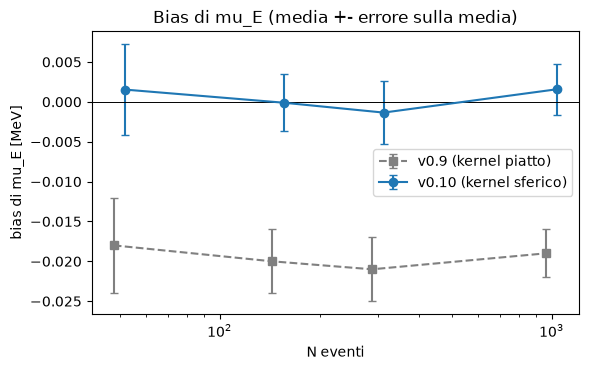

In [2]:
print(f"{'N':>5} | {'bias mu [MeV] v0.10':>22} {'v0.9':>16} | {'bias log sig':>18} {'v0.9':>6} | {'err medio Omega':>15} {'v0.9':>6}")
for n in N_VALUES:
    q, m = Q[n], len(Q[n]["mu_res"])
    b09, e09 = V09["bias_mu"][n]
    print(f"{n:5d} | {q['mu_res'].mean():+9.4f} +- {q['mu_res'].std() / np.sqrt(m):.4f}"
          f"     {b09:+.3f} +- {e09:.3f} |"
          f" {q['ls_res'].mean():+7.3f} +- {q['ls_res'].std() / np.sqrt(m):.3f} {V09['bias_ls'][n]:+6.2f} |"
          f" {np.degrees(T[n]['omega_error'].mean()):13.2f} ° {V09['err_om'][n]:5.2f}°")

fig, ax = plt.subplots(figsize=(6, 3.8))
x = np.array(N_VALUES)
b09 = np.array([V09["bias_mu"][n] for n in N_VALUES])
ax.errorbar(x * 0.96, b09[:, 0], b09[:, 1], fmt="s--", color="gray", capsize=3, label="v0.9 (kernel piatto)")
b10 = np.array([[Q[n]["mu_res"].mean(), Q[n]["mu_res"].std() / np.sqrt(len(Q[n]["mu_res"]))] for n in N_VALUES])
ax.errorbar(x * 1.04, b10[:, 0], b10[:, 1], fmt="o-", color="C0", capsize=3, label="v0.10 (kernel sferico)")
ax.axhline(0, color="k", lw=0.7)
ax.set_xscale("log")
ax.set_xlabel("N eventi")
ax.set_ylabel("bias di mu_E [MeV]")
ax.set_title("Bias di mu_E (media +- errore sulla media)")
ax.legend()
fig.tight_layout()

* **$\mu_E$**: il bias costante di circa −0.02 MeV della v0.9 è **sparito**; a ogni N è
  compatibile con zero entro mezzo errore. La causa era il kernel 1D della traccia (P1, notebook 06).
* **$\Omega_n$**: l'errore medio scende del 35–45% a ogni N, effetto dello stadio 1 iterato (P3).
* **$\log\sigma_E$**: resta il bias negativo a N piccolo, che si annulla a N = 1000. A **N = 50 è
  però circa il doppio della v0.9** (−0.27 ± 0.04 contro −0.14 ± 0.03). Vedi l'esito.

## 2. Risoluzione

Rms dell'errore reale contro l'incertezza dichiarata (media sugli esperimenti).

* **$\mu_E$**: rms e dichiarata ora coincidono a ogni N (v0.9 a N = 1000: 0.028 contro 0.019).
* **$\Omega_n$**: il rapporto rms/dichiarata passa da circa 0.8 (conservativo) a 1.08, 1.06,
  1.00, 0.90. La σ dichiarata a N = 1000 è finita (P2).
* **$\log\sigma_E$**: rms maggiore della dichiarata a N ≤ 300, come nella v0.9. La causa non è
  stata studiata **(d)**.

In [3]:
print(f"{'N':>5} | {'mu: rms / dichiarata':>22} {'v0.9':>14} | {'log sig: rms / dich.':>21} {'v0.9':>12} | {'Omega: rms / dich.':>19} {'v0.9':>13}")
for n in N_VALUES:
    q, t = Q[n], T[n]
    print(f"{n:5d} | {rms(q['mu_res']):10.4f} / {t['mu_std'].mean():.4f}   {V09['rms_mu'][n]:.3f} / {V09['std_mu'][n]:.3f} |"
          f" {rms(q['ls_res']):9.3f} / {t['ls_std'].mean():.3f}   {V09['rms_ls'][n]:.3f} / {V09['std_ls'][n]:.3f} |"
          f" {np.degrees(rms(t['omega_error'])):8.2f}° / {np.degrees(t['omega_sigma'].mean()):.2f}°  "
          f" {V09['rms_om'][n]:.2f}° / {V09['sig_om'][n]:.2f}°")

    N |   mu: rms / dichiarata           v0.9 |  log sig: rms / dich.         v0.9 |  Omega: rms / dich.          v0.9
   50 |     0.0807 / 0.0846   0.082 / 0.088 |     0.592 / 0.442   0.470 / 0.400 |     1.96° / 1.82°   3.06° / 3.87°
  150 |     0.0507 / 0.0503   0.055 / 0.051 |     0.292 / 0.193   0.260 / 0.180 |     1.11° / 1.05°   1.74° / 2.21°
  300 |     0.0393 / 0.0349   0.045 / 0.035 |     0.174 / 0.111   0.160 / 0.110 |     0.75° / 0.75°   1.24° / 1.57°
 1000 |     0.0201 / 0.0193   0.028 / 0.019 |     0.052 / 0.058   0.052 / 0.057 |     0.37° / 0.41°   0.67° / 0.82°


## 3. Pull

$\mu_E$ e $\log\sigma_E$: media / larghezza. $\Omega_n$: rms di $\delta/\hat\sigma$, dove $\delta$ è
la distanza angolare; se la calibrazione è corretta, $\sqrt2\cdot$pull segue una Rayleigh e l'rms è
1. Gli istogrammi sono a N = 150 e N = 1000.

* **$\mu_E$**: media ≈ 0 e larghezza ≈ 1 a ogni N. Nella v0.9 la media scendeva fino a −1.05.
* **$\Omega_n$**: rms 1.08, 1.05, 1.00, 0.89 contro 0.79 prima. A N = 1000 è finito: nella v0.9
  valeva circa $8\cdot10^4$.
* **$\log\sigma_E$**: larghezza ≈ 1; la media a N = 50 è −0.37 (v0.9: −0.10), coerente con il bias
  del punto 1.

    N |  pull mu (media/largh.)          v0.9 |   pull log sig          v0.9 | pull Omega rms   v0.9
   50 |      -0.02 / 1.01   -0.25 / 0.98 |  -0.37 / 0.93   -0.10 / 0.97 |           1.08   0.79
  150 |      +0.01 / 0.97   -0.40 / 0.98 |  -0.19 / 1.01   -0.02 / 1.05 |           1.05   0.78
  300 |      -0.04 / 1.14   -0.62 / 1.14 |  -0.13 / 1.07   +0.00 / 1.06 |           1.00   0.79
 1000 |      +0.06 / 1.01   -1.05 / 1.05 |  +0.08 / 0.86   +0.17 / 0.87 |           0.89    inf


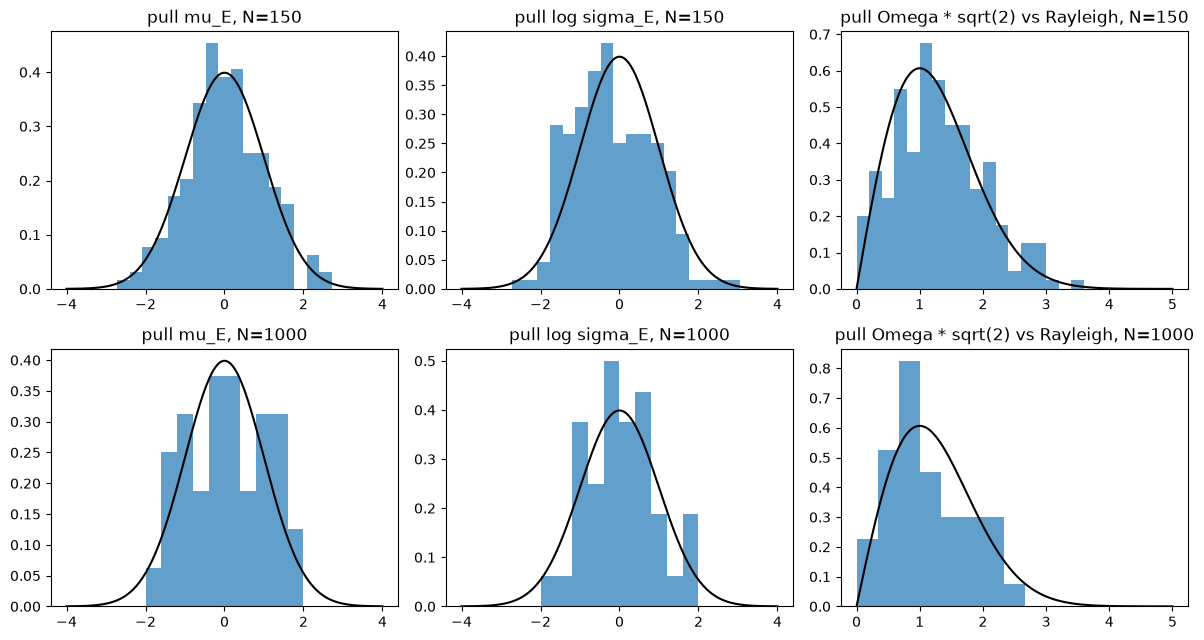

In [4]:
print(f"{'N':>5} | {'pull mu (media/largh.)':>23} {'v0.9':>13} | {'pull log sig':>14} {'v0.9':>13} | {'pull Omega rms':>14} {'v0.9':>6}")
for n in N_VALUES:
    q = Q[n]
    print(f"{n:5d} | {q['mu_pull'].mean():+10.2f} / {q['mu_pull'].std():.2f}   "
          f"{V09['pull_mu'][n][0]:+.2f} / {V09['pull_mu'][n][1]:.2f} |"
          f" {q['ls_pull'].mean():+6.2f} / {q['ls_pull'].std():.2f}  "
          f" {V09['pull_ls'][n][0]:+.2f} / {V09['pull_ls'][n][1]:.2f} |"
          f" {rms(q['om_pull']):14.2f} {V09['pull_om'][n]:6.2f}")

fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
xg, rg = np.linspace(-4, 4, 200), np.linspace(0, 5, 200)
for row, n in zip(axes, [150, 1000]):
    for ax, key, name in zip(row[:2], ["mu_pull", "ls_pull"], ["mu_E", "log sigma_E"]):
        ax.hist(Q[n][key], bins=20 if n == 1000 else 25, range=(-4, 4), density=True, alpha=0.7)
        ax.plot(xg, norm.pdf(xg), "k-")
        ax.set_title(f"pull {name}, N={n}")
    row[2].hist(Q[n]["om_pull"] * np.sqrt(2.0), bins=15 if n == 1000 else 25, range=(0, 5), density=True, alpha=0.7)
    row[2].plot(rg, rg * np.exp(-rg ** 2 / 2), "k-")
    row[2].set_title(f"pull Omega * sqrt(2) vs Rayleigh, N={n}")
fig.tight_layout()

## 4. Coverage

Errore binomiale: ±0.03/±0.02/±0.015 ai tre livelli con M = 200, ±0.05 al 68% con M = 100,
±0.07 al 68% con M = 40.

* **$\mu_E$**: nominale a N ≤ 300. A N = 1000 il 68% vale 0.57, cioè −1.5 errori binomiali
  con M = 40; al 90% e al 95% è invece sopra il nominale (0.95 e 1.00), e la larghezza del pull è
  1.01. È compatibile con una fluttuazione. Il punto aperto (d) del report §8.3 (0.55 con lo stadio
  2 della v0.9 corretta) resta così: **da ricontrollare con M più grande**, che ora costa pochi minuti.
* **$\Omega_n$**: da conservativa (circa 0.85 al 68%) a **nominale** a N = 150 e 300. A N = 50 è un
  po' sotto al 90% e al 95% (0.86 e 0.93, circa −2 e −1.3 errori binomiali). A N = 1000 il 68% vale
  0.78 (+1.4 errori).
* **$\log\sigma_E$**: nominale a N ≥ 150. **A N = 50 peggiora**: 0.82 al 90% (−3.8 errori
  binomiali) e 0.91 al 95%, contro 0.88 e 0.94 della v0.9.

coverage 68 / 90 / 95 %
    N |         mu v0.10             v0.9 |    log sig v0.10             v0.9 |      Omega v0.10             v0.9
   50 | 0.65 / 0.89 / 0.95 0.69 / 0.90 / 0.96 | 0.61 / 0.82 / 0.91 0.67 / 0.88 / 0.94 | 0.70 / 0.86 / 0.93 0.85 / 0.96 / 1.00   (+-0.03 a 0.68)
  150 | 0.70 / 0.92 / 0.95 0.66 / 0.88 / 0.94 | 0.60 / 0.87 / 0.94 0.61 / 0.87 / 0.94 | 0.65 / 0.88 / 0.93 0.87 / 0.96 / 0.98   (+-0.03 a 0.68)
  300 | 0.66 / 0.87 / 0.91 0.55 / 0.81 / 0.86 | 0.64 / 0.87 / 0.92 0.64 / 0.87 / 0.94 | 0.66 / 0.91 / 0.95 0.84 / 0.97 / 1.00   (+-0.05 a 0.68)
 1000 | 0.57 / 0.95 / 1.00 0.48 / 0.70 / 0.72 | 0.70 / 0.97 / 1.00 0.72 / 0.95 / 0.98 | 0.78 / 0.93 / 0.97 0.85 / 0.98 / 0.98   (+-0.07 a 0.68)


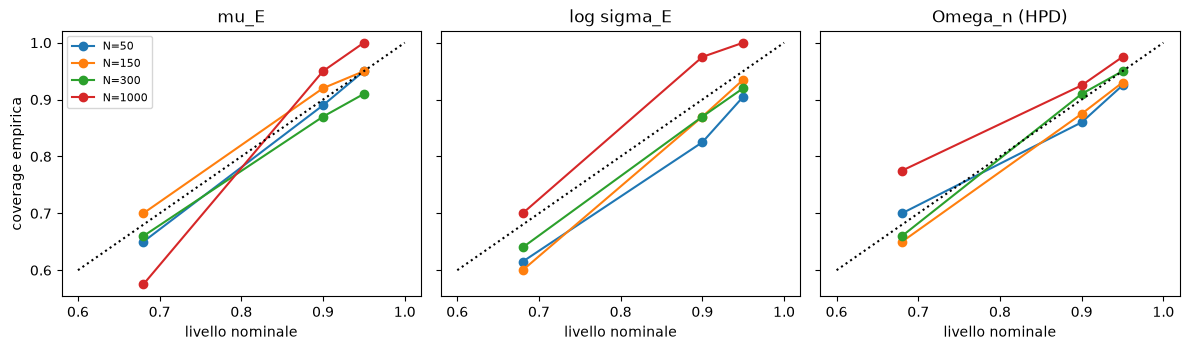

In [5]:
print("coverage 68 / 90 / 95 %")
print(f"{'N':>5} | {'mu v0.10':>16} {'v0.9':>16} | {'log sig v0.10':>16} {'v0.9':>16} | {'Omega v0.10':>16} {'v0.9':>16}")
fmt = lambda c: " / ".join(f"{v:.2f}" for v in c)
COV = {}
for n in N_VALUES:
    t = T[n]
    _, cmu = validate.coverage_curve(t["mu_true"], t["mu_int"], LEVELS)
    _, cls = validate.coverage_curve(np.log(t["sigma_true"]), t["ls_int"], LEVELS)
    com = t["omega_covered"].mean(axis=0)
    COV[n] = (cmu, cls, com)
    m = len(t["mu_true"])
    print(f"{n:5d} | {fmt(cmu):>16} {fmt(V09['cov_mu'][n]):>16} | {fmt(cls):>16} {fmt(V09['cov_ls'][n]):>16} |"
          f" {fmt(com):>16} {fmt(V09['cov_om'][n]):>16}   (+-{np.sqrt(0.68 * 0.32 / m):.2f} a 0.68)")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, k, name in zip(axes, range(3), ["mu_E", "log sigma_E", "Omega_n (HPD)"]):
    for n in N_VALUES:
        ax.plot(LEVELS, COV[n][k], "o-", label=f"N={n}")
    ax.plot([0.6, 1.0], [0.6, 1.0], "k:")
    ax.set_title(name)
    ax.set_xlabel("livello nominale")
axes[0].set_ylabel("coverage empirica")
axes[0].legend(fontsize=8)
fig.tight_layout()

## 5. Contrazione

Pendenza log-log dell'rms contro N (ideale −0.5) e rms·$\sqrt N$ (costante se ideale).
Un plateau dell'rms, cioè rms·$\sqrt N$ che cresce, segnala un sistematico condiviso.

* **$\mu_E$**: rms·$\sqrt N$ ≈ 0.6 e circa piatto, pendenza −0.46. Nella v0.9 cresceva fino a
  0.87, la firma del bias condiviso.
* **$\Omega_n$**: rms·$\sqrt N$ scende da circa 0.37 a 0.20–0.24 rad, quindi a parità di N la
  direzione è più precisa. Cala leggermente con N, e la pendenza è −0.56: il prior plug-in su $E_n$
  diventa più informativo man mano che $(\hat\mu_E, \hat\sigma_E)$ migliorano **(b)**.
* **$\log\sigma_E$**: pendenza −0.81, come nella v0.9. A N piccolo la stima è dominata dal prior.

mu         pendenza -0.460 (v0.9 -0.360)  rms*sqrt(N) = [0.571 0.621 0.681 0.637]  (v0.9 (0.577, 0.677, 0.772, 0.872))
log sigma  pendenza -0.811 (v0.9 -0.735)  rms*sqrt(N) = [4.188 3.572 3.014 1.644]  (v0.9 (3.32, 3.15, 2.79, 1.64))
Omega      pendenza -0.559 (v0.9 -0.505)  rms*sqrt(N) = [0.242 0.238 0.227 0.204]  (v0.9 (0.378, 0.371, 0.375, 0.371))


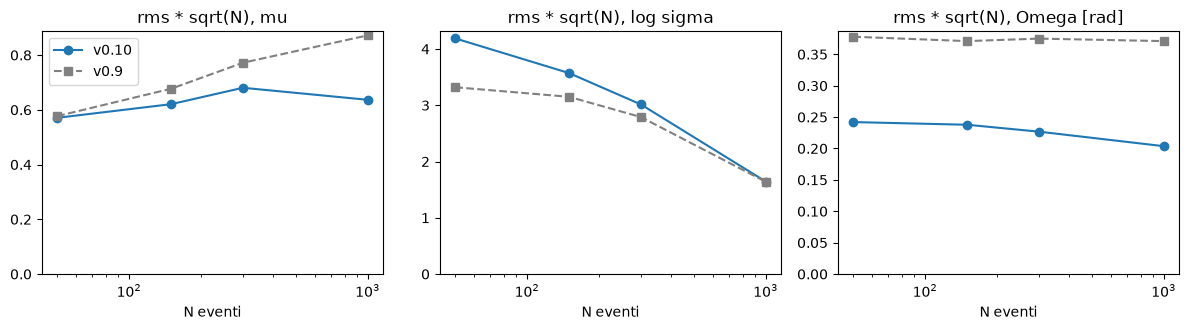

In [6]:
curves = {
    "mu": np.array([rms(Q[n]["mu_res"]) for n in N_VALUES]),
    "log sigma": np.array([rms(Q[n]["ls_res"]) for n in N_VALUES]),
    "Omega": np.array([rms(T[n]["omega_error"]) for n in N_VALUES]),
}
sqrtN = np.sqrt(N_VALUES)
for name, c in curves.items():
    slope = np.polyfit(np.log(N_VALUES), np.log(c), 1)[0]
    print(f"{name:10s} pendenza {slope:+.3f} (v0.9 {V09['slope'][name]:+.3f})  "
          f"rms*sqrt(N) = {np.round(c * sqrtN, 3)}  (v0.9 {V09['rms_sqrtN'][name]})")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, (name, c) in zip(axes, curves.items()):
    ax.plot(N_VALUES, c * sqrtN, "o-", label="v0.10")
    ax.plot(N_VALUES, V09["rms_sqrtN"][name], "s--", color="gray", label="v0.9")
    ax.set_xscale("log")
    ax.set_ylim(bottom=0)
    ax.set_title(f"rms * sqrt(N), {name}" + (" [rad]" if name == "Omega" else ""))
    ax.set_xlabel("N eventi")
axes[0].legend()
fig.tight_layout()

## 6. Robustezza al prior

Stesso dataset a N = 150, stadio 2 con prior uniforme in $\sigma_E$ invece che in
$\log\sigma_E$; spostamenti in unità di deviazione standard posteriore.

Il comportamento è invariato rispetto alla v0.9: $\mu_E$ è insensibile al prior, mentre
$\log\sigma_E$ si sposta in media di +0.16σ, con un massimo di 0.8σ, e la coverage resta nominale.

In [7]:
t_log, t_lin = collect(run["results"], N_ROB, "logU"), collect(run["results"], N_ROB, "U")
d_mu = (t_lin["mu_mean"] - t_log["mu_mean"]) / t_log["mu_std"]
d_ls = (t_lin["ls_median"] - t_log["ls_median"]) / t_log["ls_std"]
_, cov_lin = validate.coverage_curve(np.log(t_lin["sigma_true"]), t_lin["ls_int"], LEVELS)
print(f"N={N_ROB}, prior uniforme in sigma_E vs uniforme in log sigma_E (spostamenti in std posteriori):")
print(f"  mu:        medio {d_mu.mean():+.3f}, max |.| {np.abs(d_mu).max():.3f}   (v0.9: -0.01, 0.15)")
print(f"  log sigma: medio {d_ls.mean():+.3f}, max |.| {np.abs(d_ls).max():.3f}   (v0.9: +0.15, 0.68)")
print(f"  coverage log sigma con prior U: {fmt(cov_lin)}   (v0.9: 0.59 / 0.89 / 0.95)")

N=150, prior uniforme in sigma_E vs uniforme in log sigma_E (spostamenti in std posteriori):
  mu:        medio -0.011, max |.| 0.145   (v0.9: -0.01, 0.15)
  log sigma: medio +0.159, max |.| 0.810   (v0.9: +0.15, 0.68)
  coverage log sigma con prior U: 0.62 / 0.90 / 0.95   (v0.9: 0.59 / 0.89 / 0.95)


## 7. Una verifica sulla regressione a N = 50

Ipotesi **(d)**: lo stadio 1 iterato usa i dati due volte (report §8.3, effetto $O(1/N)$). Se
$\hat\sigma_E$ è sottostimato, il prior su $E_n$ è troppo stretto, Ω_n risulta troppo
sicura e lo stadio 2 finale vede uno spettro più stretto. Se l'ipotesi è giusta, negli
esperimenti in cui $\sigma_E$ è sottostimato il pull di Ω dovrebbe essere più grande.

In [8]:
from scipy.stats import spearmanr

print(f"{'N':>5} | {'Spearman(res log sig, pull Omega)':>34} | {'pull Omega rms: sig sotto / sopra mediana':>40}")
for n in N_VALUES:
    q = Q[n]
    low = q["ls_res"] < np.median(q["ls_res"])
    r = spearmanr(q["ls_res"], q["om_pull"])
    print(f"{n:5d} | {r.statistic:+18.2f} (p = {r.pvalue:.3f})     | "
          f"{rms(q['om_pull'][low]):18.2f} / {rms(q['om_pull'][~low]):.2f}")

    N |  Spearman(res log sig, pull Omega) | pull Omega rms: sig sotto / sopra mediana
   50 |              -0.13 (p = 0.074)     |               1.07 / 1.09
  150 |              -0.04 (p = 0.560)     |               1.12 / 0.97
  300 |              -0.17 (p = 0.101)     |               1.05 / 0.94
 1000 |              -0.01 (p = 0.967)     |               0.94 / 0.84


La correlazione per esperimento è debole e **non significativa**. Questo test quindi non
conferma il meccanismo, ma nemmeno lo esclude: il pull di Ω è rumoroso esperimento per esperimento.
Il test diretto è ripetere N = 50 con lo stadio 1 a prior largo, come la riga "largo" della tabella
§8.3, e confrontare bias e coverage di $\log\sigma_E$.

## Esito

| parametro | v0.9 | v0.10 |
|---|---|---|
| $\Omega_n$ | conservativa (pull rms ≈ 0.79); σ degenere a N = 1000 | **calibrata** a N ≥ 150 e circa 40% più precisa; lievemente sovra-confidente a N = 50 |
| $\mu_E$ | bias −0.02 MeV, coverage 0.48 a N = 1000 | **calibrata** a ogni N; bias compatibile con 0; contrazione $1/\sqrt N$ |
| $\sigma_E$ | calibrata | calibrata a N ≥ 150; **a N = 50 bias −0.27 e coverage 90% = 0.82** |

P1 e P2 sono chiusi **(c)**. P3 è chiuso a N ≥ 150. A N = 50 lo stadio 1 iterato ha un costo su
$\sigma_E$ che va ancora capito.

**Punti aperti**

1. Regressione di $\log\sigma_E$ (e un po' di $\Omega_n$) a N = 50 **(d)**. Test diretto: prior
   largo contro iterato a N = 50. Possibili rimedi da discutere: iterare solo sopra una soglia di N,
   oppure stimare $\sigma_E$ con l'$\hat\Omega_n$ a prior largo.
2. Coverage 68% di $\mu_E$ a N = 1000 (0.57 con M = 40) **(d)**: da rifare con M ≥ 100.